# Random Boolean network generation

This tutorial demonstrates how to generate **random Boolean networks with
controlled structural and functional properties** using BoolForge.
This ability enables ensemble studies, which are exemplified in the next tutorial.

## What you will learn
In this tutorial you will learn how to generate random Boolean networks with

- prescribed structural properties (e.g., degree, degree distribution, strongly connected),
- prescribed functional properties (e.g., canalization, bias),

It is strongly recommended to complete Tutorials 4 and 5 on random function generation first.

## Setup

In [1]:
import boolforge as bf
import numpy as np
import matplotlib.pyplot as plt

## Generating random wiring diagrams

The function `random_network(N, n, *args)` generates a random $N$-node
Boolean network with degree parameter `n`. 
The generation follows a two-step process:

- A random wiring diagram is created using `random_wiring_diagram(N, n, *args)`.
- Random Boolean functions with prescribed properties are generated using 
  `random_function(n, *args)`, which was discussed in depth in Tutorials 4 and 5.

We first consider only the structural parameters that concern the generation of
the random wiring diagram. In the absence of optional arguments,
the in-degree distribution is assumed to be constant. That is, each node in the 
network is regulated by `n` nodes.

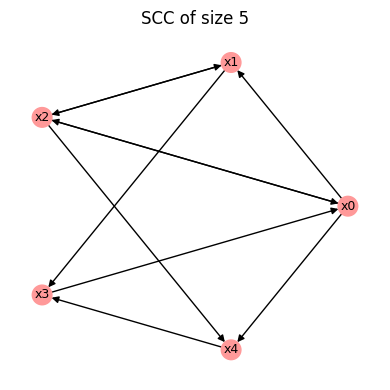

In [2]:
N = 5
n = 2

W = bf.random_wiring_diagram(N, n, rng=2)

W.plot();

The argument `rng` seeds the random number generator, ensuring reproducible results.

The rest of this tutorial describes the various constraints / optional arguments. 
Each optional argument restricts the family of networks from which
`random_wiring_diagram()` and `random_network()` samples.

### Allowing self-regulation

BoolForge selects the `n` regulators of each node uniformly at random
from the set of all other nodes. Thus, self-regulation is disallowed by default.
Setting `allow_self_loops=True` allows nodes to regulate themselves.

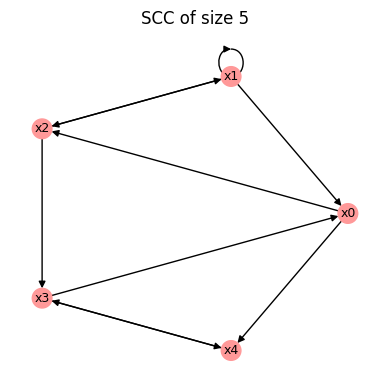

In [3]:
N = 5
n = 2

W = bf.random_wiring_diagram(N,n,allow_self_loops=True,rng = 2)

W.plot();

### Poisson in-degree distributions

Classical random Boolean network theory (NK Kauffman models) assume a fixed in-degree,
the default in BoolForge. However, this is a strong assumption since the in-degree
in curated biological Boolean network models often appears approximately
Poisson distributed.
BoolForge provides the option to generate random wiring diagrams with Poisson distributed
in-degree, using the optional parameter `indegree_distribution`.

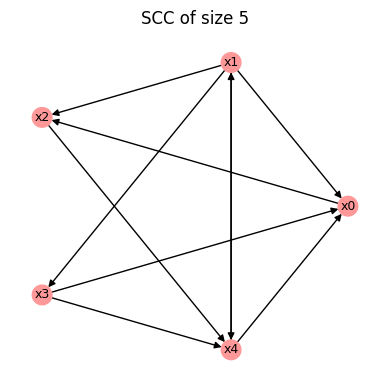

In [4]:
N = 5
n = 2

W = bf.random_wiring_diagram(N,n,indegree_distribution='poisson',rng = 5)

W.plot();

We see that some nodes ($x_1$ and $x_3$) are only regulated by one node,
while others ($x_0$ and $x_4$) possess three regulators each.

When using a Poisson-distributed in-degree, the in-degree of every node 
is always at least 1. This avoids the artificial creation of identity nodes
(with in-degree 0).

### Avoiding output nodes

In general, it is possible that some nodes in a generated Boolean network 
will not regulate other nodes. By setting `min_out_degree_one=True`, we can
force every node to regulate at least one node. That is, output nodes can be disallowed.

### Strong connectedness

The wiring diagram of the generated Boolean network may or may not be strongly
connected. Setting `strongly_connected=True` (default False) forces strong
connectedness. Uniform sampling among strongly connected networks cannot be achieved by
a simple construction method. BoolForge therefore generates candidate
networks and rejects them until a strongly connected network is obtained.

Careful: When the number of nodes `N` is large and the degree `n` is small, this may take a
long time. The number of unsuccessful attempts before raising an error is controlled
by the optional parameter `max_strong_connectivity_attempts`. 

### Fixed wiring diagrams

All optional parameters discussed thus far describe properties of the wiring diagram.
Instead of generating a new wiring diagram, an existing one (e.g., from a curated
biological network model) can be passed directly to `random_network`.

In that case, `random_network(I, *args)` does not require `N` and `n`, because
these quantities are inferred from the wiring diagram, provided via optional parameter `I`.
As described in detail in Tutorial 6, `I` can be either a `WiringDiagram` object 
or a list of lists describing the regulators of each node.

For example, using the previously generated wiring diagram, we can write

In [5]:
bn = bf.random_network(I=W)

This feature allows multiple Boolean networks with different update functions
to be generated on the same wiring diagram.

## Specifying functional constraints

Once the wiring diagram is generated, the number of nodes `N` and the in-degree of each node are determined.
In step 2, `random_network` now repeatedly calls `random_function` to generate 
the random Boolean functions. The optional parameters regulating the functional constraints
are practically identical to the ones discussed in depth in Tutorial 4, with one
important distinction: Most parameters can be sequences of length `N`, in order to
specify distinct functional behavior for the different nodes.

In the following, we summarize the key concepts.

### Parity functions
If `parity=True` (default False), parity functions (also known as linear functions)
are chosen for all nodes. Note that for any degree `n`, there are only two parity functions.

### Canalizing functions
If a specific `layer_structure` is provided, all functions possess at least these
canalizing layers.

In [6]:
bn = bf.random_network(N=4,n=3,layer_structure=[1],rng = 2)
for f in bn.F:
    print(f,f.get_layer_structure()['LayerStructure'])

[0 1 1 0 0 0 0 0] [1]
[0 0 1 1 0 1 1 1] [1, 2]
[0 0 0 0 0 0 0 1] [3]
[1 1 1 0 1 1 1 1] [3]


As we see, it is however possible for some functions to randomly possess more canalizing
variables in a larger and/or more layers. To ensure `layer_structure` is interpreted
as exact layer structure, set `exact_depth=True`. 

In [7]:
bn = bf.random_network(N=4,n=3,layer_structure=[1],exact_depth=True,rng = 2)
for f in bn.F:
    print(f,f.get_layer_structure()['LayerStructure'])

[0 1 1 0 0 0 0 0] [1]
[1 0 1 1 0 1 1 1] [1]
[1 1 0 1 0 1 1 1] [1]
[0 1 1 0 1 1 1 1] [1]


Rather than specifying the exact layer structure, we can also describe the desired
*canalizing depth* (i.e., the number of conditionally canalizing variables) via `depth`. 
As before, the optional argument `exact_depth` (default False) determines if 
`depth` is interpreted as exact canalizing depth, or as minimum canalizing depth.

In [8]:
#Boolean network whose rules all have minimal canalizing depth 1
bn1 = bf.random_network(N=4,n=3,depth=1,exact_depth=False,rng = 2)
for f in bn1.F:
    print(f.get_canalizing_depth(),f) 
print()    

#Boolean network whose rules all have exact canalizing depth 1
bn2 = bf.random_network(N=4,n=3,depth=1,exact_depth=True,rng = 2)
for f in bn2.F:
    print(f.get_canalizing_depth(),f) 

1 [0 1 1 0 0 0 0 0]
3 [0 0 0 0 0 0 1 0]
3 [1 1 0 0 1 1 1 0]
3 [0 1 1 1 0 0 0 0]

1 [0 1 1 0 0 0 0 0]
1 [1 0 0 0 0 0 1 0]
1 [1 1 0 1 0 1 1 1]
1 [0 0 1 0 1 0 0 0]


Most optional parameters (e.g., `n`, `depth`, `layer_structure`, `bias`, `absolute_bias`) 
can also be specified as sequences of length `N`.
In that case, each entry applies to one node in the network, allowing
different functional constraints for different nodes.

In [9]:
bn = bf.random_network(
    N=4,
    n=[3,3,2,2],
    depth=[3,1,2,0],
    exact_depth=True,
    rng=2
)

for f in bn.F:
    print(f.get_canalizing_depth(),f) 

3 [1 1 1 1 0 1 1 1]
1 [1 1 0 1 0 1 1 1]
2 [1 1 0 1]
0 [0 1 1 0]


### Biased functions
When `parity=False` and all canalization parameters are also at their default values,
`random_network` generates each update function with a specified *bias*, i.e.

  - probability of output 1: `bias`
  - probability of output 0: `1-bias`

The unbiased case (`bias=0.5`) is the default. Instead of the bias, users can
also specify the absolute bias to generate functions with a bimodal Hamming weight
distribution. For BoolForge to use the parameter provided via `absolute_bias`, 
`use_absolute_bias=True` is required. The default is `use_absolute_bias=False`, 
i.e., by default `bias` is used, resulting in a unimodal Hamming weight distribution.

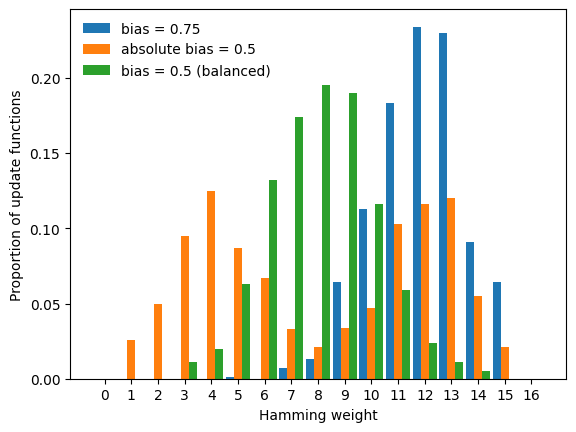

In [10]:
N = 1000 #network size
n = 4   #constant in-degree

bn1 = bf.random_network(N=N,n=n,bias=0.75)
bn2 = bf.random_network(N=N,n=n,absolute_bias=0.5,use_absolute_bias=True)
bn3 = bf.random_network(N=N,n=n,absolute_bias=0.5)
bns = [bn1,bn2,bn3]

labels = ["bias = 0.75", "absolute bias = 0.5", "bias = 0.5 (balanced)"]
possible_hamming_weights = np.arange(2**n + 1)
width = 0.3

fig, ax = plt.subplots()
for i,bn in enumerate(bns):
    count = np.zeros(2**n + 1)
    for f in bn.F:
        count[f.hamming_weight] += 1
    ax.bar(possible_hamming_weights - width + i * width, 
           count / N, 
           width=width, label=labels[i])

ax.legend(frameon=False)
ax.set_xticks(possible_hamming_weights)
ax.set_xlabel("Hamming weight")
ax.set_ylabel("Proportion of update functions");

## Summary

In this tutorial you learned how to:

- generate random wiring diagrams with prescribed structural constraints,
- generate, for each node in a wiring diagram, random update functions 
  with prescribed functional constraints.

In the next tutorial, we will explore several situations, in which the ability
to generate large ensembles of controlled random Boolean networks is very useful. 